# 05 · 场图 (fieldplot 替代)

腔场 Ez/Er/Bφ 二维图 + 轴上场; 螺线管 Bz 二维图 + 轴上曲线 (离轴场按手册第 8 章展开)。

In [1]:
%run _bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
from pathlib import Path
CAVITY_FILE = PROJECT_ROOT / "examples/Manual_Example/3_cell_L-Band.dat"
SOLENOID_FILE = PROJECT_ROOT / "examples/Manual_Example/Solenoid.dat"
print("腔场文件:", CAVITY_FILE, CAVITY_FILE.exists())
print("螺线管文件:", SOLENOID_FILE, SOLENOID_FILE.exists())

腔场文件: /Users/yuxinwu/my_projects/astra_notebook/examples/Manual_Example/3_cell_L-Band.dat True
螺线管文件: /Users/yuxinwu/my_projects/astra_notebook/examples/Manual_Example/Solenoid.dat True


腔场: 343 个 z 点, 峰值 Ez = 14610.53 (任意单位, 按 MaxE 缩放)


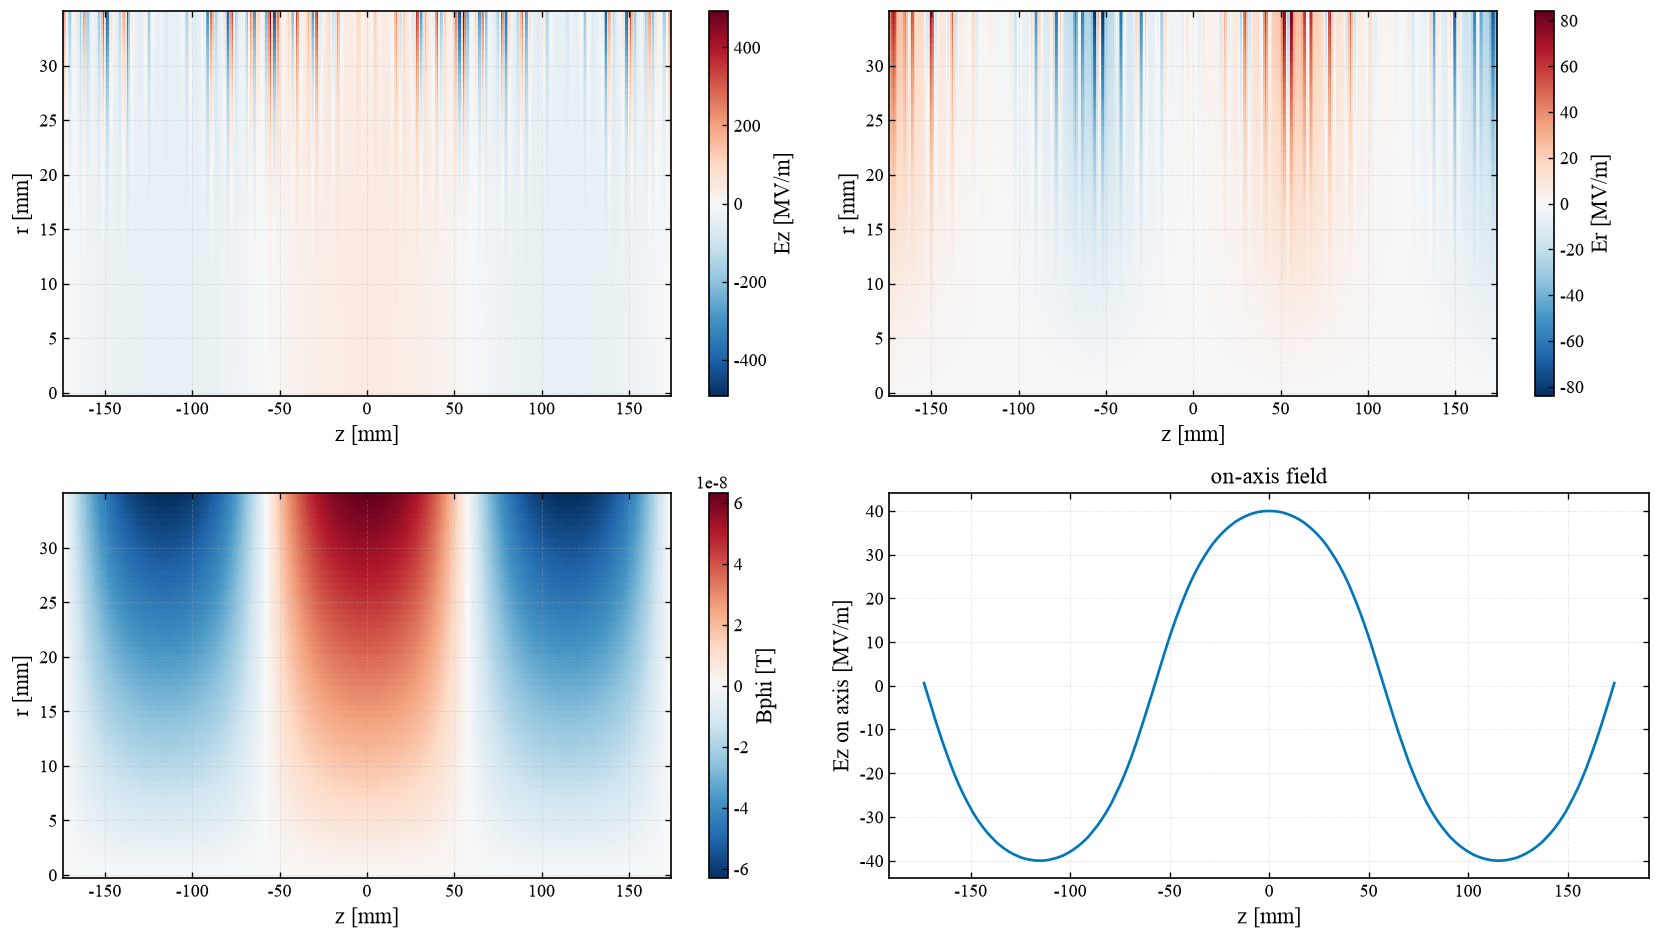

In [3]:
from astra_tools.io.field_map import read_cavity_field
from astra_tools.plot.field_plots import plot_cavity_field
import numpy as np
cav = read_cavity_field(CAVITY_FILE)
print("腔场: %d 个 z 点, 峰值 Ez = %.2f (任意单位, 按 MaxE 缩放)" % (len(cav.z), cav.peak_field_arb))
# Bφ 由 RF 角频率产生 (手册 8 章); 不传 omega 则 Bφ=0, 该面板会空白
OMEGA_RF = 2 * np.pi * 1.3e9   # L-band
plot_cavity_field(cav, omega=OMEGA_RF, maxE_MVpm=40);


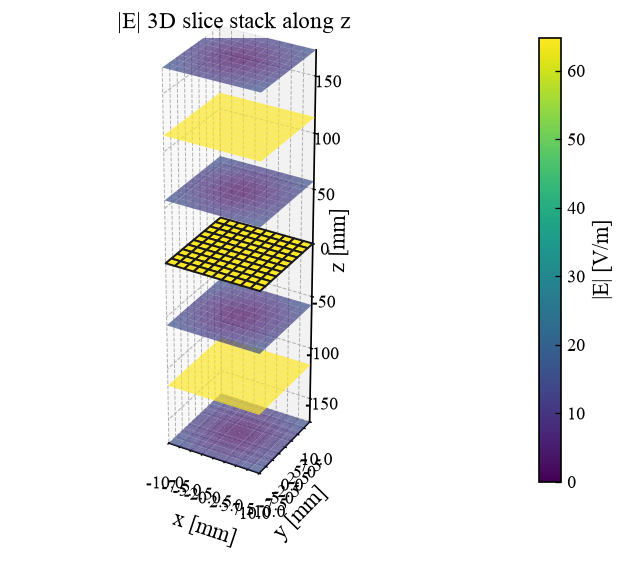

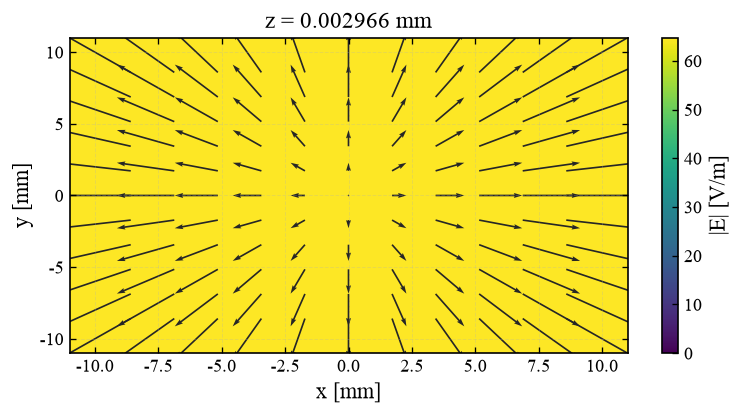

In [4]:
# 3D 场图 (fieldplot 菜单 2 现代版): 上半为半透明切片栈 + 当前切片高亮
# (3D 全景), 下半为 2D 剖面 (heatmap/contour + 面内箭头), 拖动位置滑块
# 两者联动步进 (类 postpro 步进滑块)。腔场取 plane="xy" 沿 z 步进看横向剖面; kind 切 2D 剖面画法。
from astra_tools.widgets import interact_3d_field_map
from IPython.display import display
from pathlib import Path
m3d = PROJECT_ROOT / "examples/Cavity_Example/3D_test"
if (PROJECT_ROOT / "examples/Cavity_Example/3D_test.ex").exists():
    display(interact_3d_field_map(m3d, kind="heatmap", plane="xy"))
else:
    print("3D 场图文件不存在")


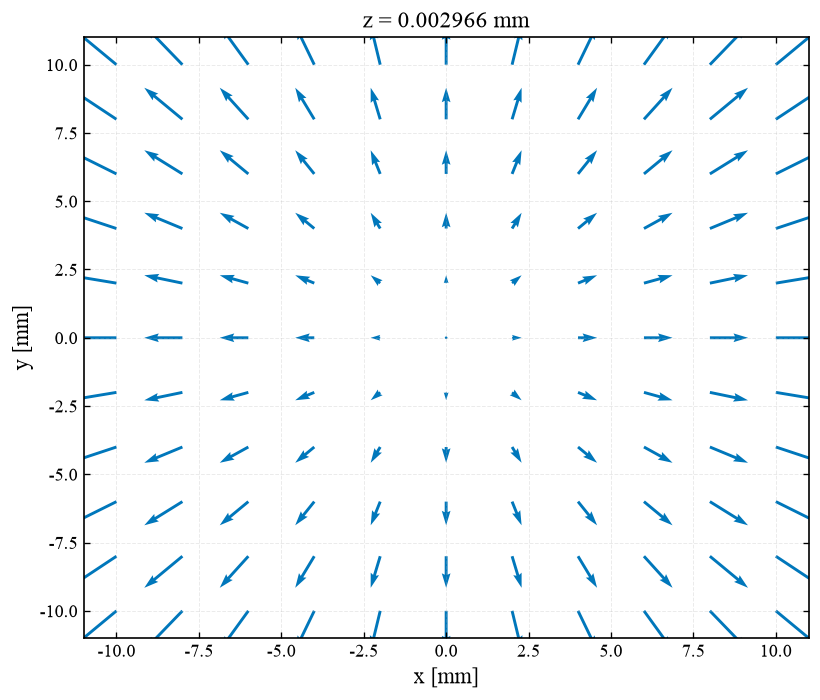

In [5]:
# 纯 2D quiver 剖面 (无底色): 同样选平面 + 位置滑块步进,
# 箭头 = 面内分量 (plane='xy' -> (fx,fy); 'xz'/'yz' 中 z 在横轴)。
from astra_tools.widgets import interact_3d_field_quiver
from IPython.display import display
m3d = PROJECT_ROOT / "examples/Cavity_Example/3D_test"
if (PROJECT_ROOT / "examples/Cavity_Example/3D_test.ex").exists():
    display(interact_3d_field_quiver(m3d, plane="xy"))
else:
    print("3D 场图文件不存在")


螺线管: 1200 个 z 点, 峰值 Bz = 0.350 T (MaxB=0.35)


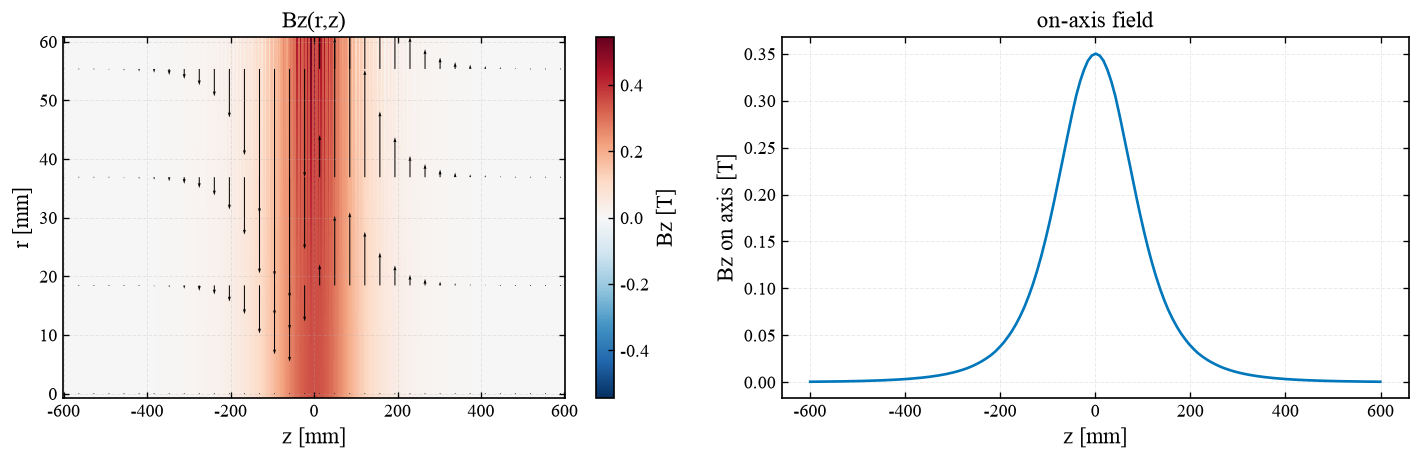

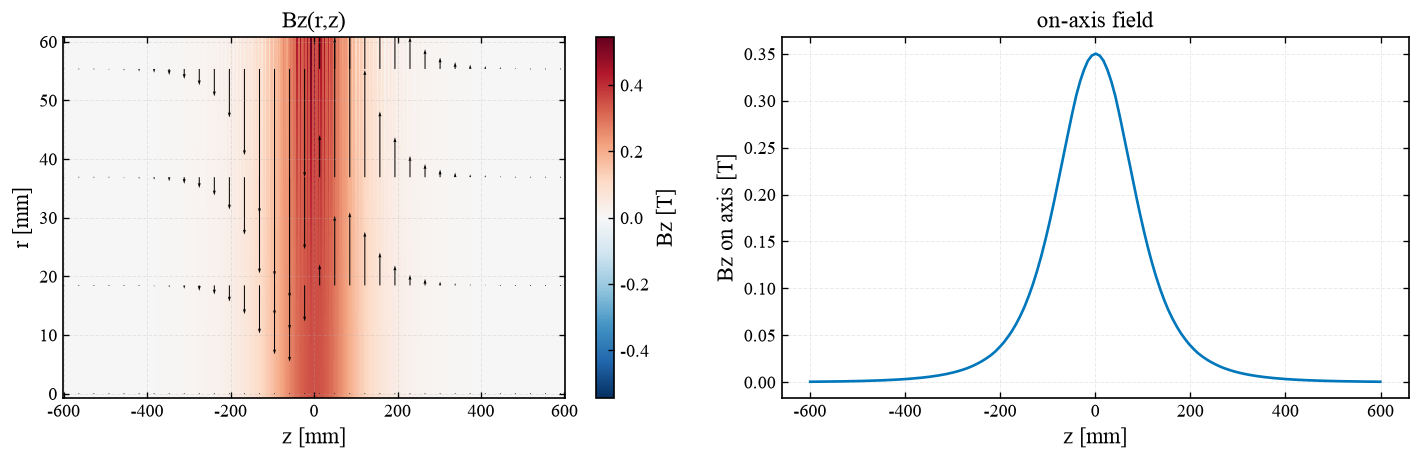

In [6]:
from astra_tools.io.field_map import read_solenoid_field
from astra_tools.plot.field_plots import plot_solenoid_field
sol = read_solenoid_field(SOLENOID_FILE).scaled(0.35)
print("螺线管: %d 个 z 点, 峰值 Bz = %.3f T (MaxB=0.35)" % (len(sol.z), sol.bz0.max()))
plot_solenoid_field(sol)

## 弯曲阴极 + 场剖面 + 空间电荷场 (fieldplot 菜单 1 项 5/6/7/8/10)

弯曲阴极轮廓 (Contour.dat, 手册 4.4.5)、一维场剖面 (四极/二极梯度)、
track 探针上的空间电荷场 (Er/Ez 简化)。


无 track 文件 (OUTPUT 中 TrackS=F, 空间电荷场不可用)


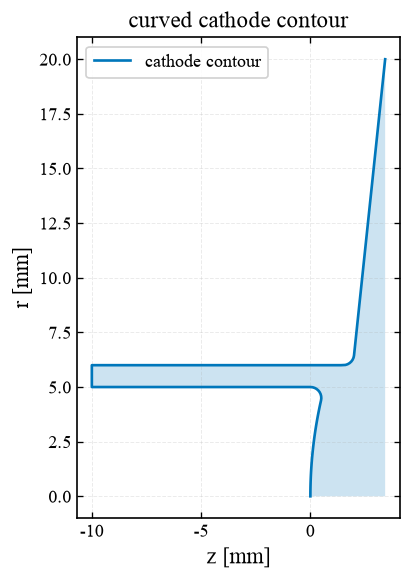

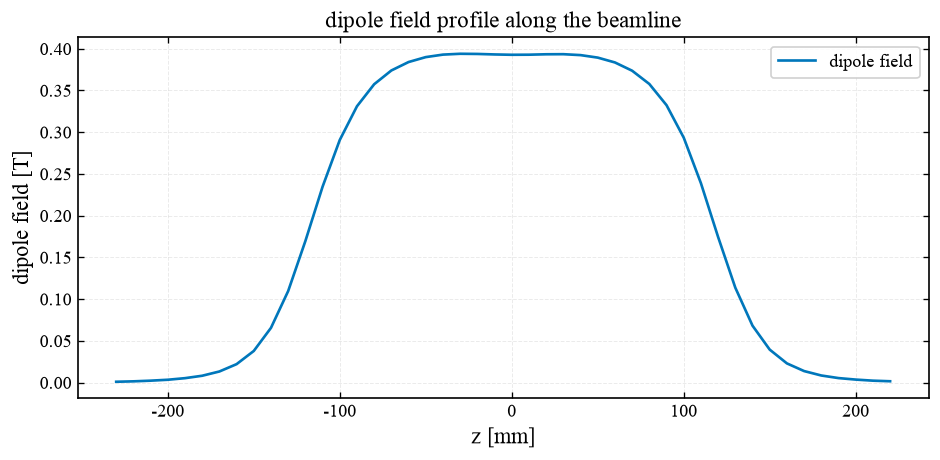

In [7]:
# 弯曲阴极轮廓 (菜单 1 项 8) + 一维场剖面 (项 5/6/7) + 空间电荷场 (项 10 简化)
from astra_tools.plot.advanced_plots import (
    plot_curved_cathode_contour, plot_field_profile, plot_space_charge_fields)
from pathlib import Path

# 弯曲阴极 (Contour.dat, 前两列 (z,R) 坐标, 手册 4.4.5)
cc = PROJECT_ROOT / "examples/Curved_Cathode_Example/Contour.dat"
if cc.exists():
    plot_curved_cathode_contour(cc, title="curved cathode contour")
else:
    print("无 Contour.dat")

# 一维场剖面 (二极/四极梯度)
fp = PROJECT_ROOT / "examples/WHPS_LINAC/115-143/bfld_scand.dat"
if fp.exists():
    plot_field_profile(fp, label="dipole field", unit="T",
                       title="dipole field profile along the beamline")
else:
    print("无场剖面文件")

# 空间电荷场 (track 探针上的 Er/Ez; TrackS=T 时生成)
tr = SIM_DIR / "astra.track.001"
if tr.exists():
    plot_space_charge_fields(tr, "Ez")
    plot_space_charge_fields(tr, "Er")
else:
    print("无 track 文件 (OUTPUT 中 TrackS=F, 空间电荷场不可用)")


## 阴极表面场 (Cathode 文件: 加速场 + 空间电荷场 + 发射电荷)

无 Cathode 文件 (CathodeS=F), 使用合成教学数据


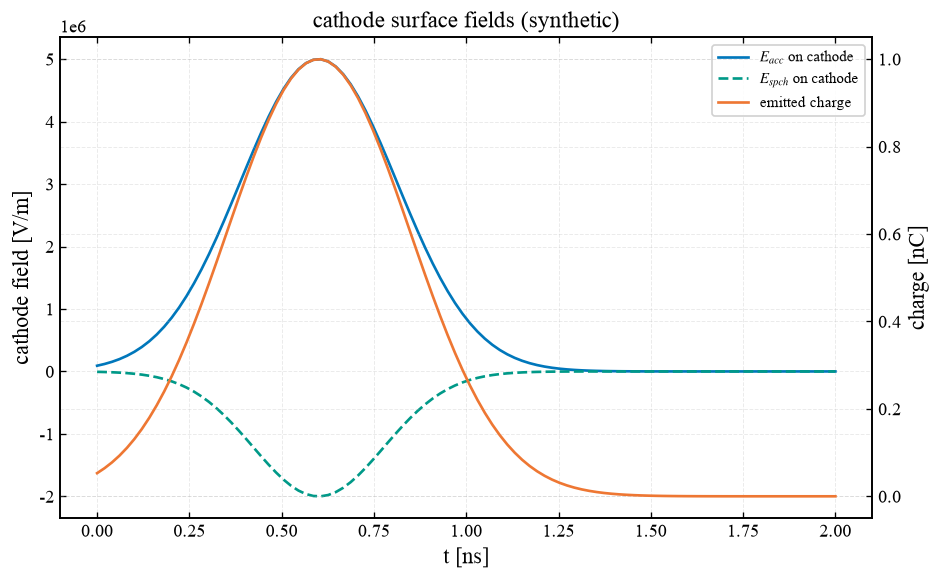

In [8]:
# 阴极表面场 (CathodeS=T 时生成 <stem>.Cathode.<run>); 缺失时用合成数据演示
from astra_tools.plot.advanced_plots import plot_cathode_emission
from pathlib import Path
cfile = SIM_DIR / "astra.Cathode.001"
if cfile.exists():
    plot_cathode_emission(cfile, include_spch=True)
else:
    # 合成教学数据 (真实文件换路径即可); 注意 charge 列单位为 nC (手册 Table 4)
    import numpy as np
    _t = np.linspace(0, 2e-9, 100)
    cathode = dict(
        t=_t,
        E_acc=5e6 * np.exp(-((_t - 0.6e-9) / 0.3e-9) ** 2),
        E_spch=-2e6 * np.exp(-((_t - 0.6e-9) / 0.25e-9) ** 2),
        q=1.0 * np.exp(-((_t - 0.6e-9) / 0.35e-9) ** 2))
    plot_cathode_emission(cathode,
                          title="cathode surface fields (synthetic)")
    print("无 Cathode 文件 (CathodeS=F), 使用合成教学数据")


## 激光 3D 图的轴上剖面 (fieldplot 菜单: Plasma fields vs z/t)

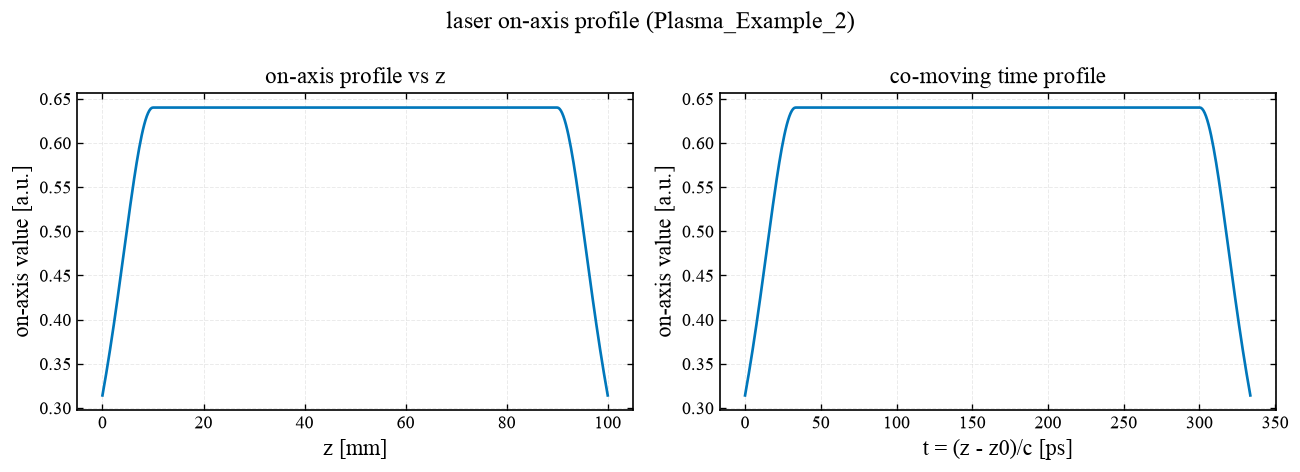

In [9]:
# 激光 3D 图轴上剖面 (File_A0 格式, fieldplot 菜单 3); 缺失时合成小图
from astra_tools.plot.advanced_plots import plot_laser_on_axis
from pathlib import Path
laser_real = PROJECT_ROOT / "examples/Plasma_Example_2/laser.dat"
if laser_real.exists():
    plot_laser_on_axis(laser_real, unit="a.u.",
                       title="laser on-axis profile (Plasma_Example_2)")
else:
    # 合成 3D 场图走同一条读图/画图路径
    import numpy as np
    laser = SIM_DIR / "demo_laser.dat"
    if not laser.exists():
        nx, ny, nz = 21, 21, 200
        x = np.linspace(-1e-3, 1e-3, nx)
        y = np.linspace(-1e-3, 1e-3, ny)
        z = np.linspace(0, 2e-3, nz)
        XX, YY, ZZ = np.meshgrid(x, y, z, indexing="ij")
        f = np.exp(-(XX ** 2 + YY ** 2) / (0.3e-3) ** 2) * np.exp(
            -((ZZ - 1e-3) / 0.4e-3) ** 2)
        with open(laser, "w") as fh:
            for g in (x, y, z):
                fh.write("%d " % len(g)
                         + " ".join("%.8g" % v for v in g) + chr(10))
            np.savetxt(fh, f.ravel(order="F"))
    plot_laser_on_axis(laser, unit="a.u.",
                       title="laser on-axis profile (synthetic)")
    print("真实 laser.dat 缺失, 使用合成教学图")


## 等离子体密度剖面 (File_Efield='Plasma...' 两列表)

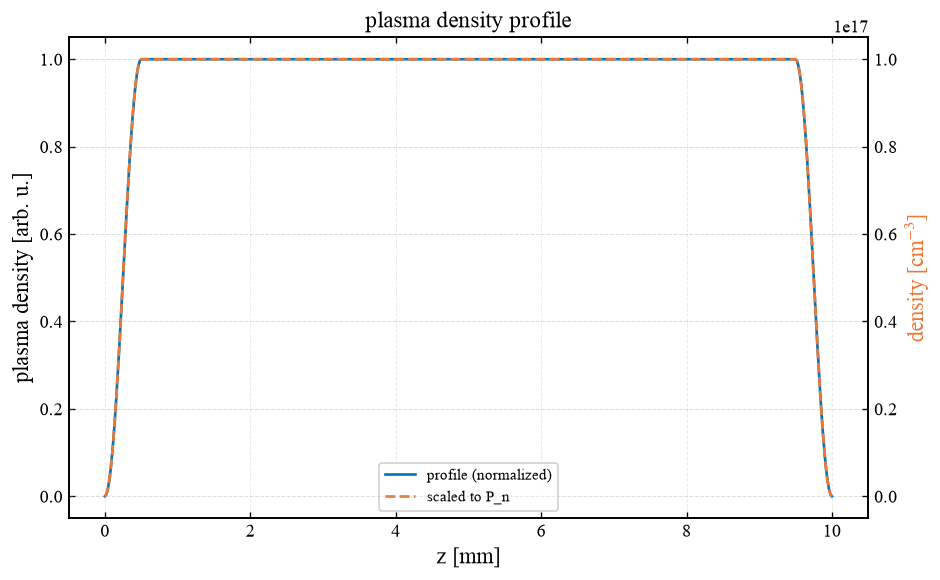

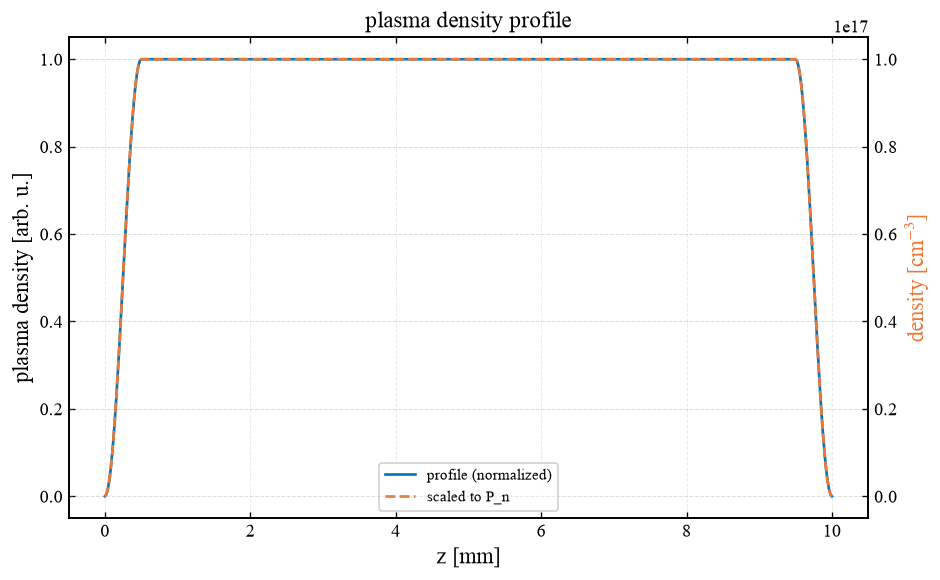

In [10]:
from astra_tools.plot.advanced_plots import plot_plasma_profile
from pathlib import Path
pfile = PROJECT_ROOT / "examples/Plasma_Example_1/PLASMA_flattop.txt"
plot_plasma_profile(pfile, peak_density_cm3=1e17)

## TE 模场 (手册 6.9: 文件名 'TE_' 前缀, 表存轴上纵向磁场 Bz; 离轴按第 8 章展开)

TE 模场文件只有一列轴上纵向磁场 Bz(z)。Bz(r,z)/Br(r,z)/Eφ(r,z) 由手册
第 8 章的 TE 展开重建 (含 ω²/c² 项)。Eφ 需要 RF 角频率 (L-band ≈ 1.3 GHz)。


已读文件 TE 场: 201 个 z 点, 峰值 Bz = 1.000 (MaxE 指轴上 Bz)


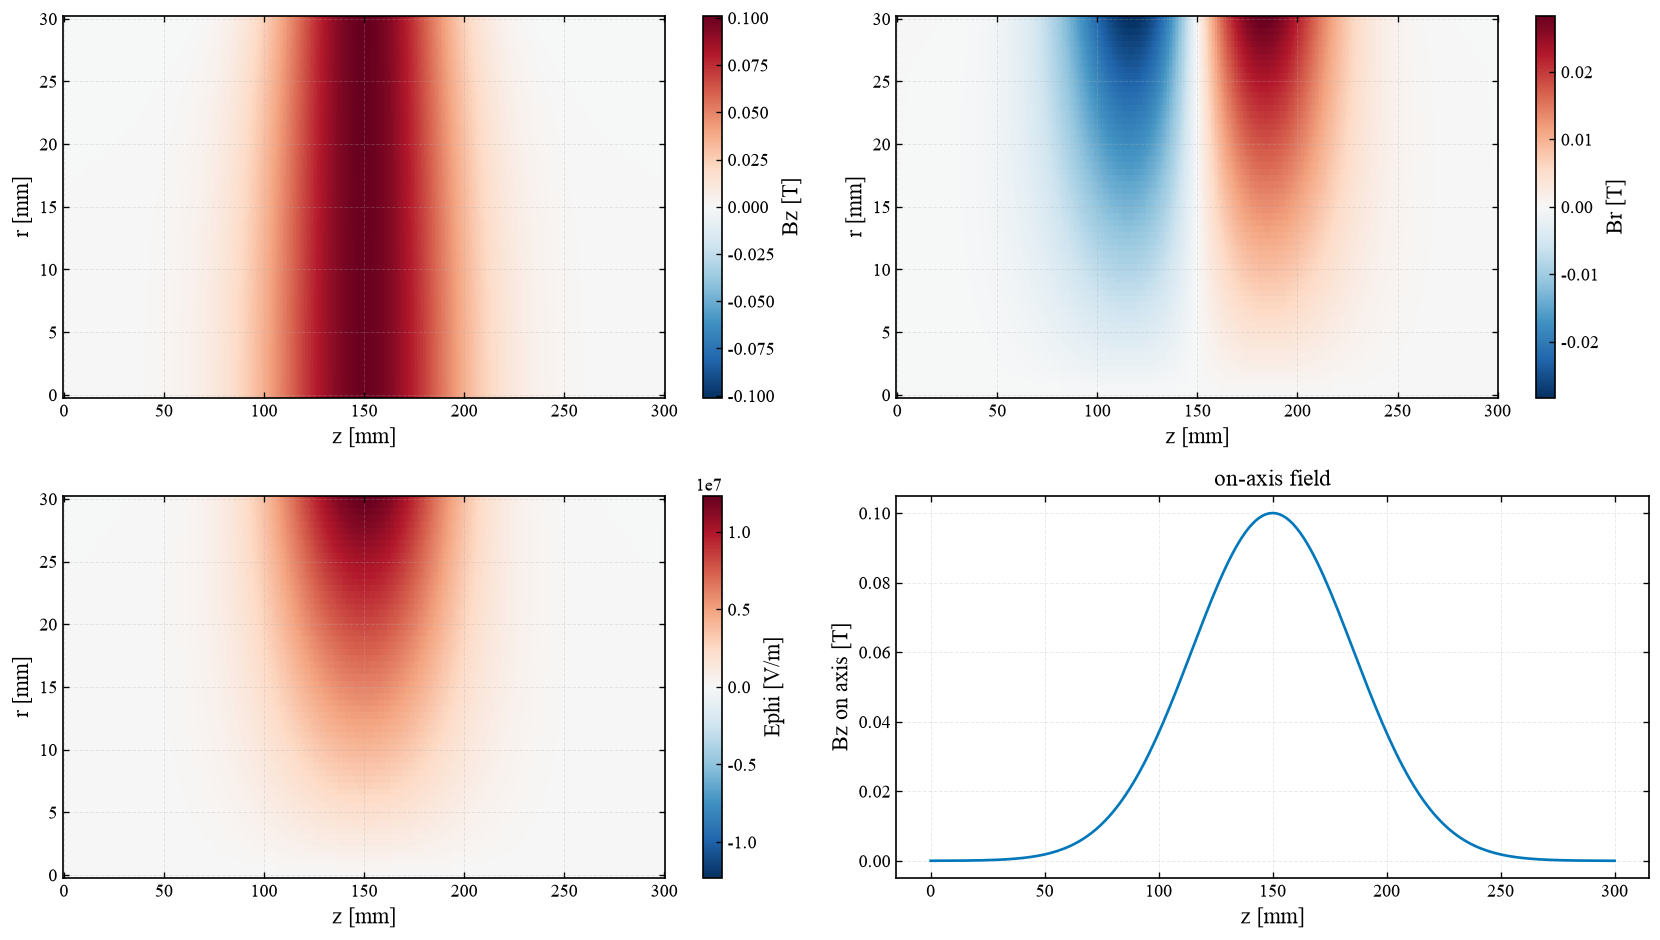

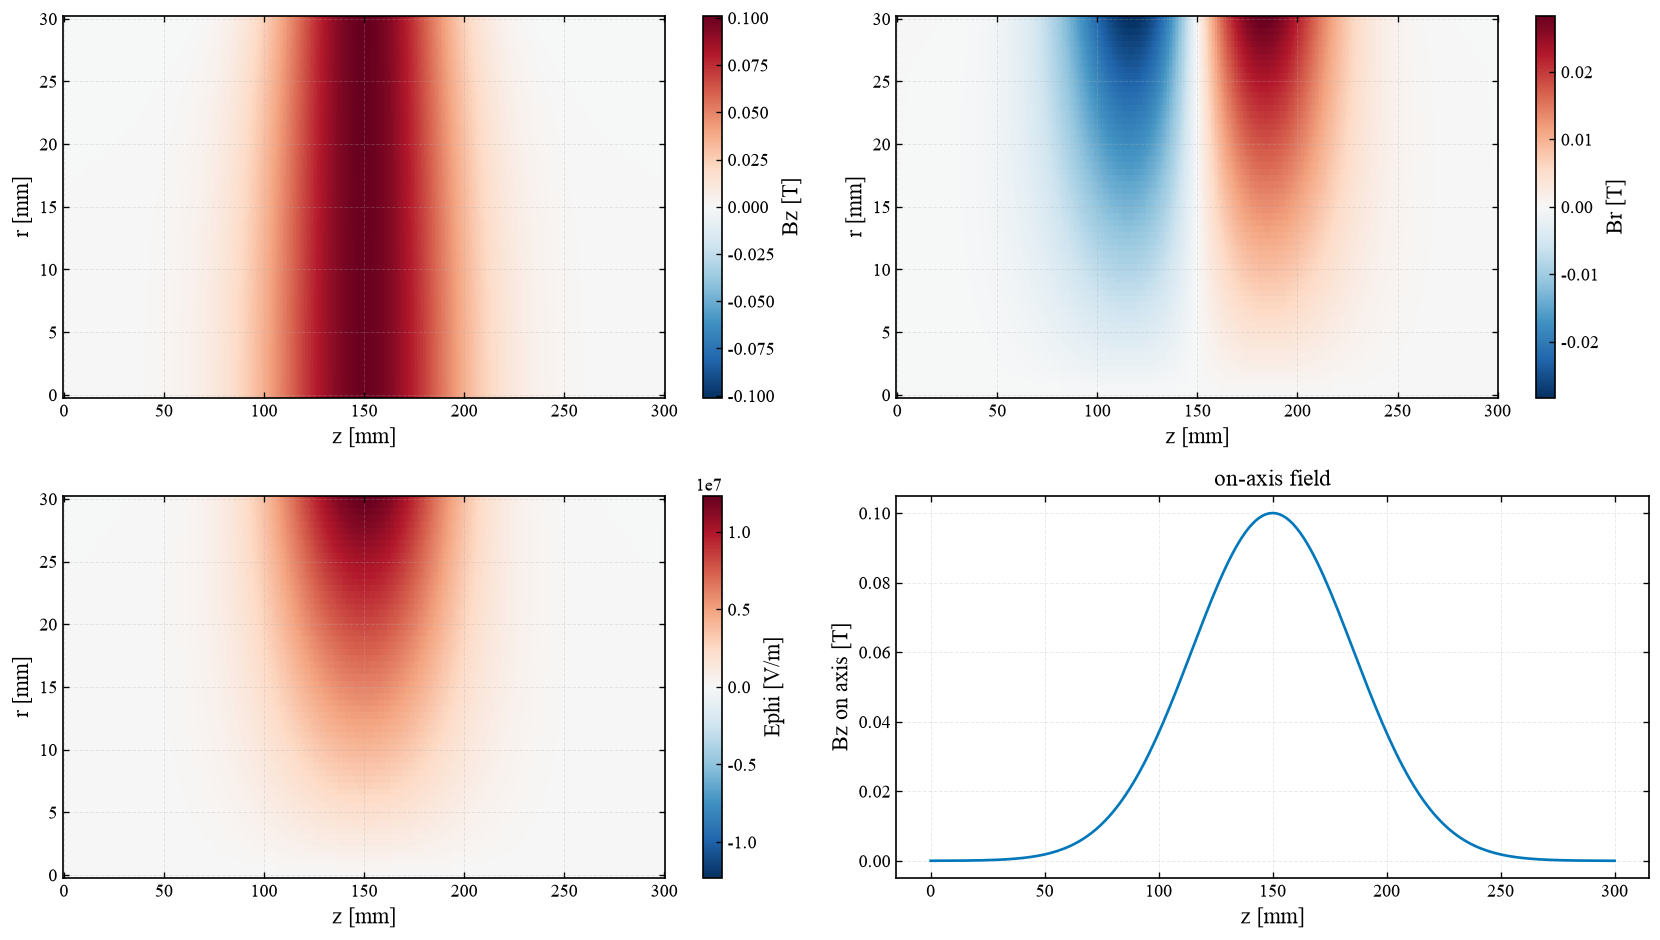

In [11]:
# TE 模场图 (Bz/Br/Eφ 二维 + 轴上 Bz); 真实 TE 文件 (如 TE_BGUN.dat) 换路径即可
from astra_tools.io.field_map import read_te_field
from astra_tools.plot.field_plots import plot_te_field
import numpy as np
from pathlib import Path
te_file = SIM_DIR / "TE_demo.dat"
if te_file.exists():
    te = read_te_field(te_file)
    src = "已读文件"
else:
    _z = np.linspace(0, 0.3, 201)
    _mu, _sig = 0.15, 0.05
    np.savetxt(te_file, np.column_stack([_z, np.exp(-((_z - _mu) / _sig) ** 2)]))
    te = read_te_field(te_file)
    src = "合成"
# omega = 2π·1.3 GHz (L-band); TE 模 Eφ 由 RF 角频率产生 (手册 8 章)
OMEGA_RF = 2 * np.pi * 1.3e9
print("%s TE 场: %d 个 z 点, 峰值 Bz = %.3f (MaxE 指轴上 Bz)" % (src, len(te.z), te.peak_field_arb))
plot_te_field(te, omega=OMEGA_RF, max_field=0.1)


## 场展开半径 R3rd (手册第 8 章诊断量)

R3rd 是场展开的有效半径, 超出后三阶项不再可忽略。分别对 TM 腔 (Er/Bφ)、
TE 模 (Eφ/Br)、螺线管 (静磁) 计算。注意该量对场表数值噪声敏感,
退化处 (导数近零) 显示为 NaN 并被跳过。


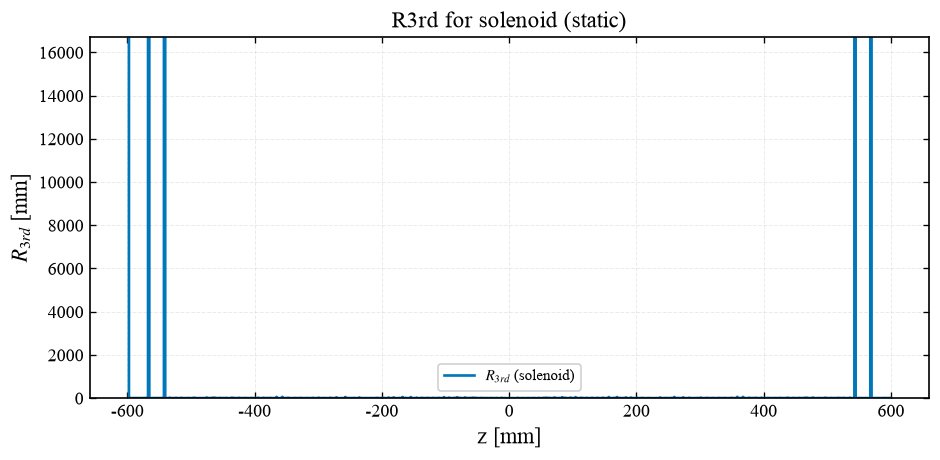

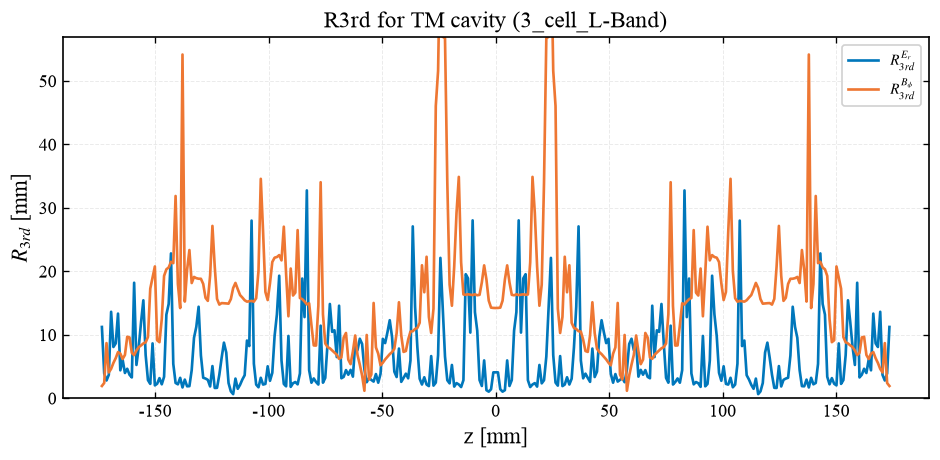

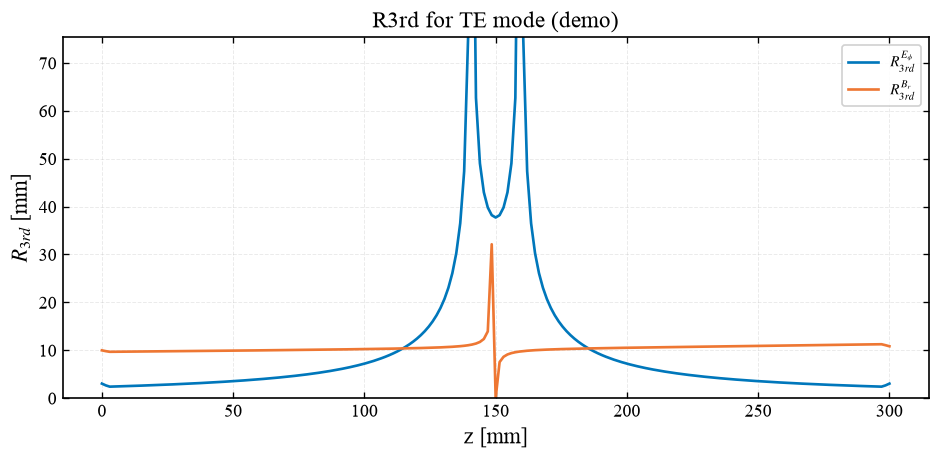

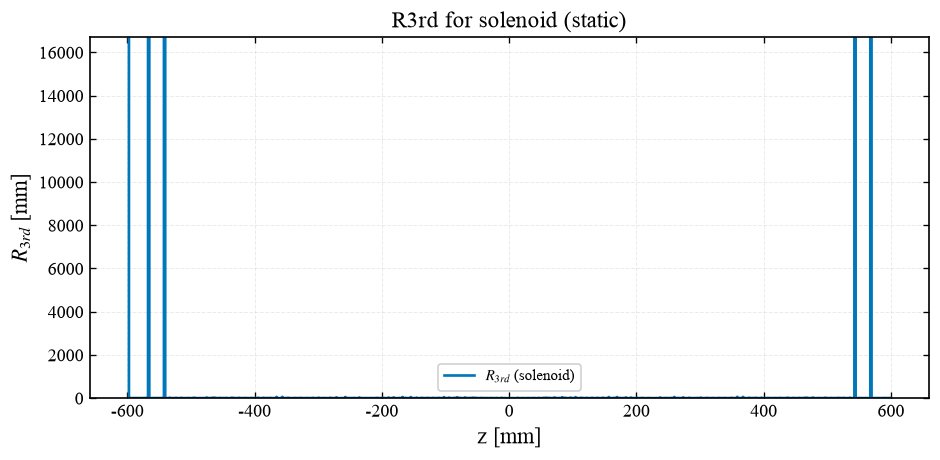

In [12]:
# 场展开半径 R3rd vs z (TM 腔 / TE 模 / 螺线管)
from astra_tools.plot.field_plots import plot_field_expansion_radius
plot_field_expansion_radius(cav, omega=OMEGA_RF,
                            title="R3rd for TM cavity (3_cell_L-Band)")
plot_field_expansion_radius(te, omega=OMEGA_RF,
                            title="R3rd for TE mode (demo)")
plot_field_expansion_radius(sol, title="R3rd for solenoid (static)")


## 螺线管 next page + 四极 next page (菜单 4/5)

螺线管 next page: 单独 Bz / 单独 Br + 场展开半径 R3rd。
四极 next page: 纵向磁场 Bz + 各分量综合图 (理想四极无边缘场, Bz=0)。


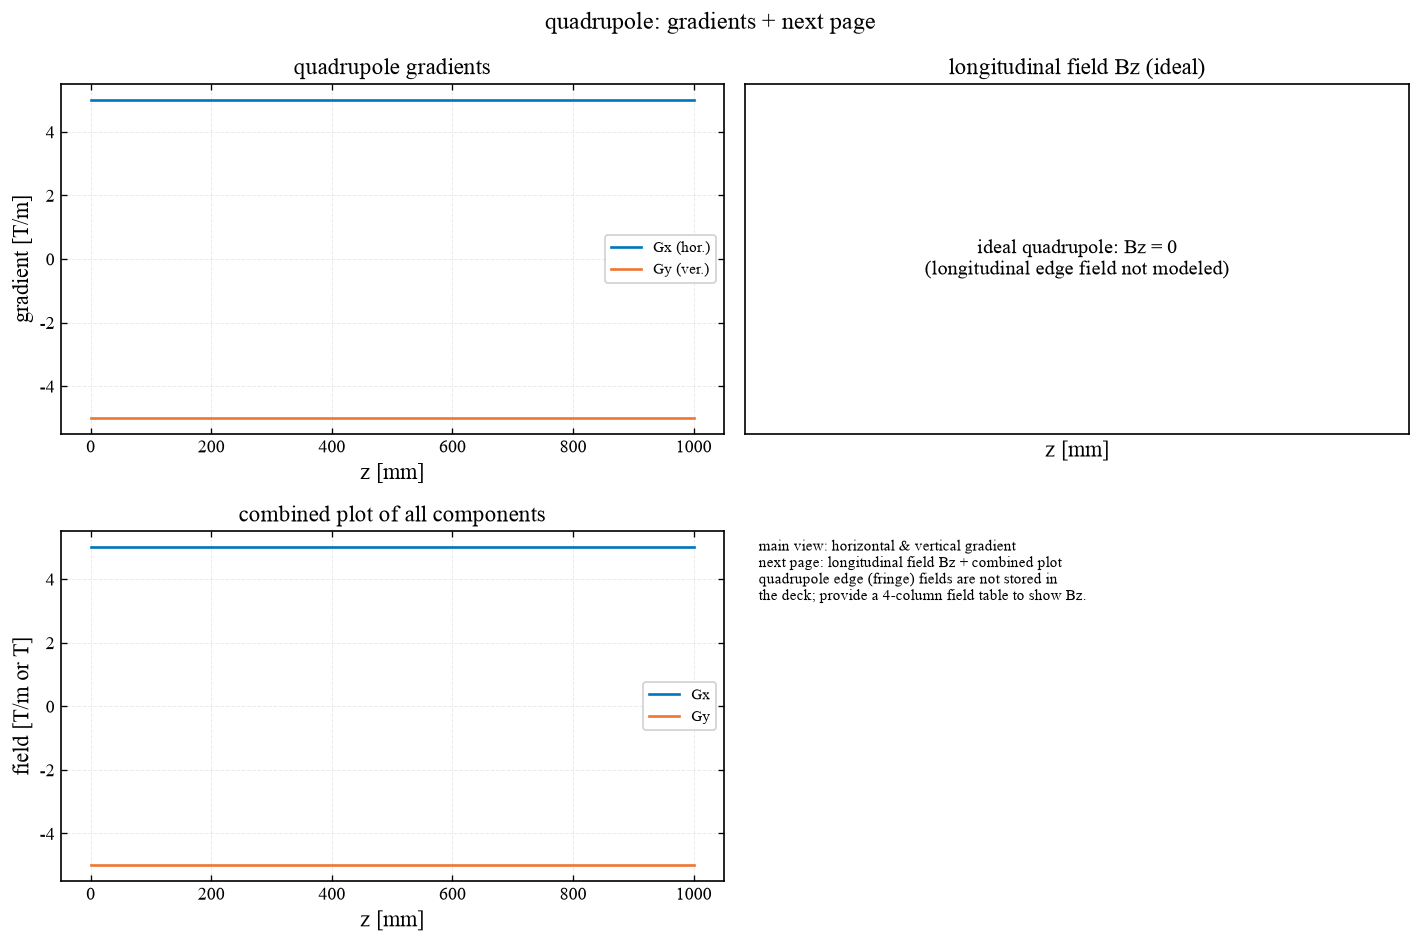

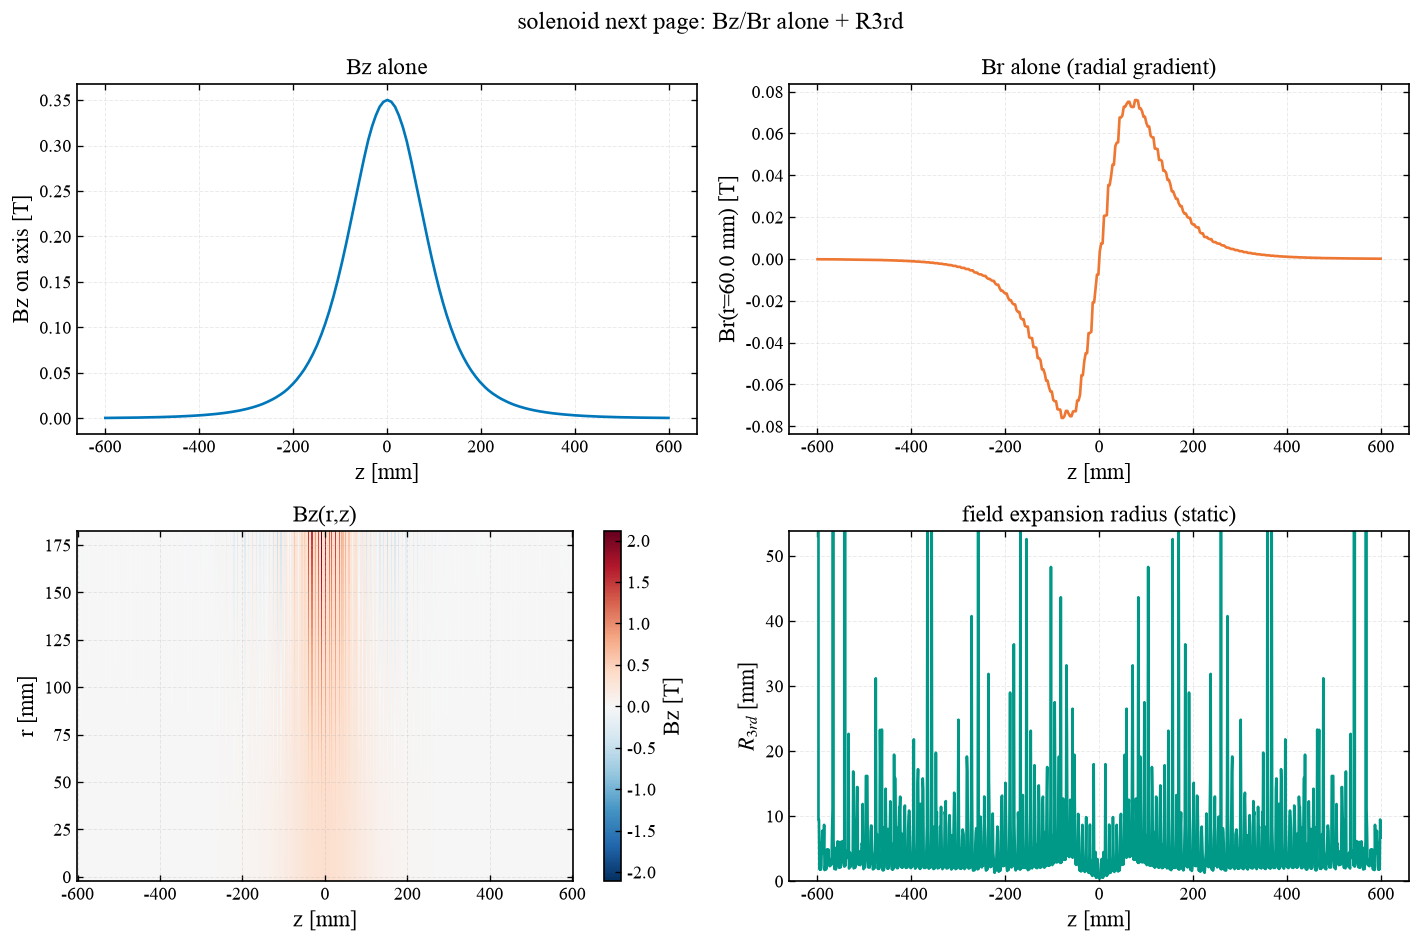

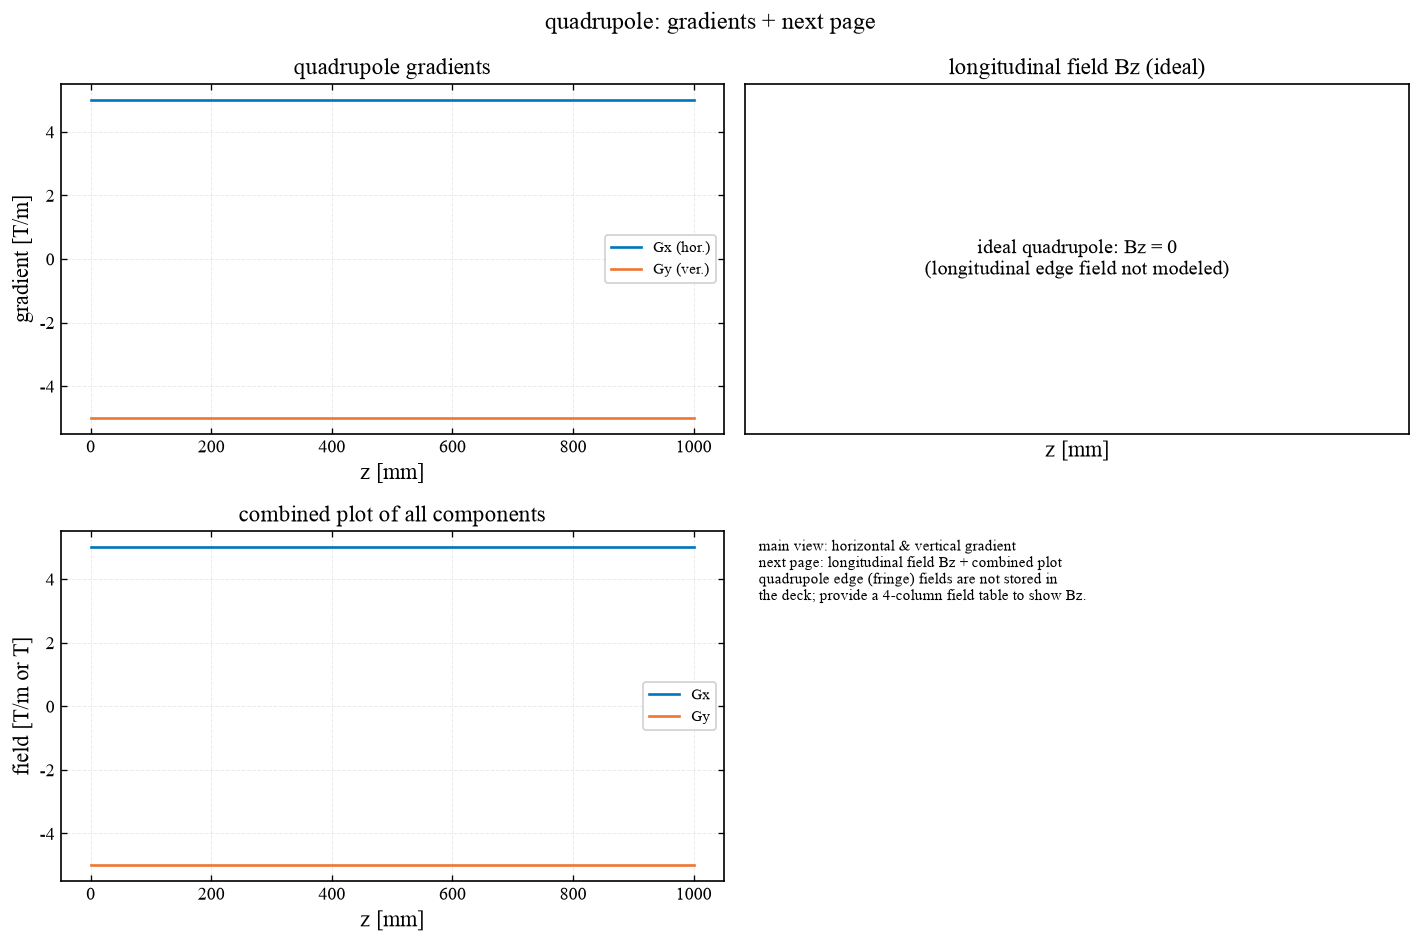

In [13]:
# 螺线管 next page (单独 Bz/Br + R3rd) + 四极 next page (Bz + 综合图)
from astra_tools.plot.field_plots import plot_solenoid_components
from astra_tools.plot.advanced_plots import plot_quadrupole_field
from pathlib import Path
plot_solenoid_components(sol, title="solenoid next page: Bz/Br alone + R3rd")
# 四极: 真实场表 (z, Gx, Gy [, Bz]) 换路径即可; 两列 (z, G) 用理想 Gy=-Gx
qfile = SIM_DIR / "quad_demo.dat"
if not qfile.exists():
    import numpy as np
    _qz = np.linspace(0, 1.0, 80)
    np.savetxt(qfile, np.column_stack([_qz, 5 * np.ones(80),
                                       -5 * np.ones(80)]))
plot_quadrupole_field(qfile, title="quadrupole: gradients + next page")


## 激光 rms 束包络 + 焦点位置 (5.7.3 项 1-6 补充)

对激光 3D 场图每个 z 切片以光强 f² 为权重计算 rms 横向半径,
显示束包络 σx(z), σy(z), 并标注焦点 (σ 最小) 位置。


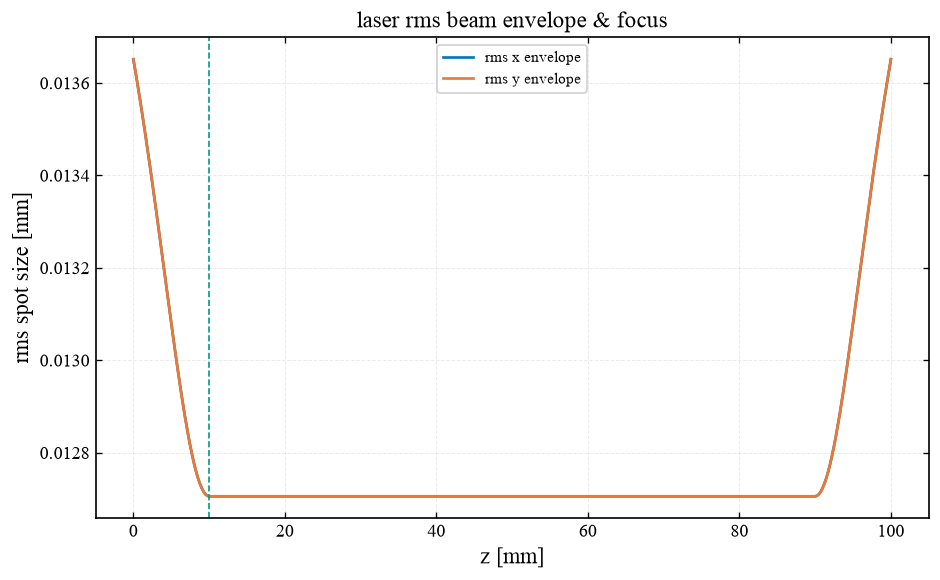

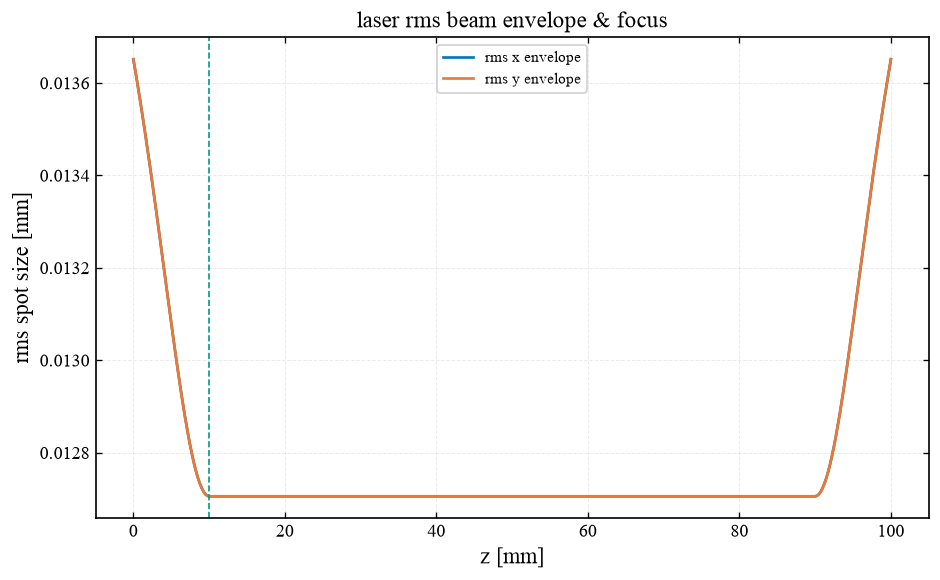

In [14]:
# 激光 rms 束包络 + 焦点位置 (5.7.3); 用上面已读的 laser (真实或合成)
from astra_tools.plot.advanced_plots import plot_laser_envelope
laser_src = laser_real if laser_real.exists() else laser
plot_laser_envelope(laser_src, title="laser rms beam envelope & focus")


## 弯曲阴极电荷环 + 等离子体场 vs z/zeta (菜单 8 / 5.7.3 项 8/9)

弯曲阴极 next page: 每个表点后方一个电荷环 (修正非平面阴极镜象电荷,
手册 4.4.5)。等离子体场: 线性尾场解析模型 (手册附录), vs z 与 vs zeta
(共动参数 ζ = z - c t)。


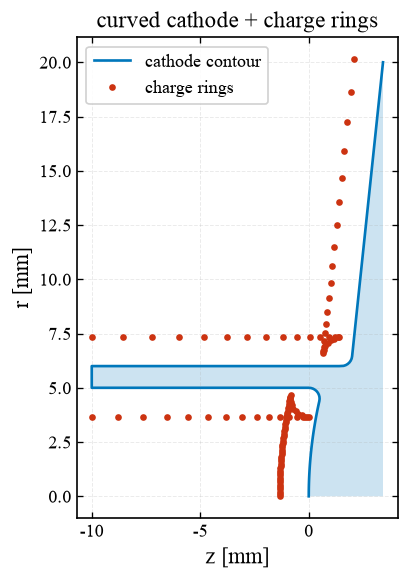

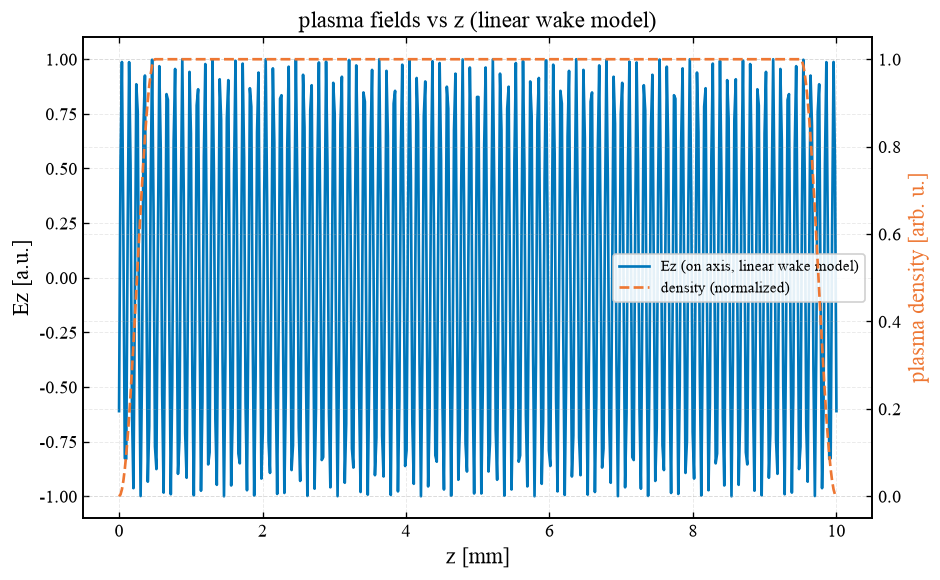

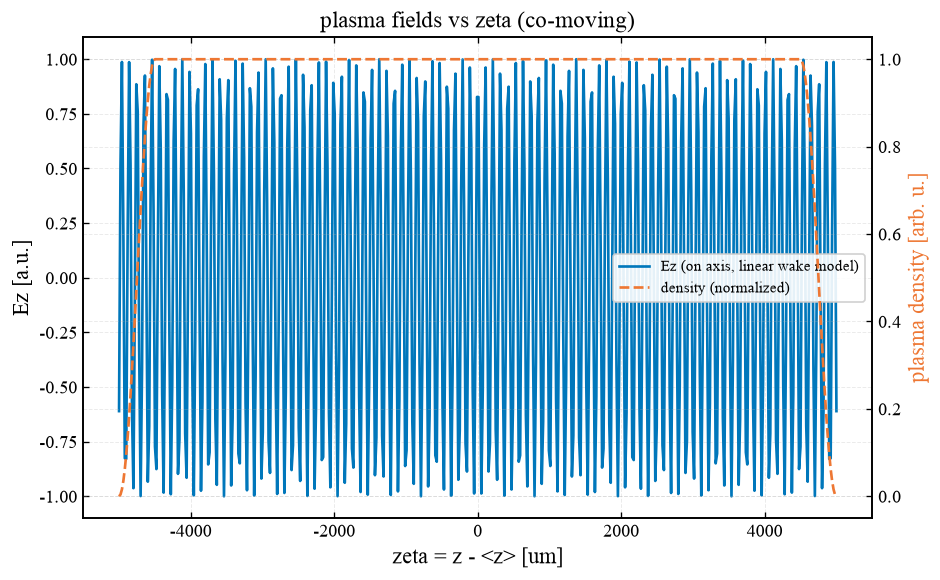

In [15]:
# 弯曲阴极电荷环位置 + 等离子体场 vs z / vs zeta
from astra_tools.plot.advanced_plots import (
    plot_curved_cathode_contour, plot_plasma_fields)
cc = PROJECT_ROOT / "examples/Curved_Cathode_Example/Contour.dat"
if cc.exists():
    plot_curved_cathode_contour(cc, show_rings=True,
                                title="curved cathode + charge rings")
else:
    print("无 Contour.dat")
if pfile.exists():
    plot_plasma_fields(pfile, peak_density_cm3=1e17, vs="z",
                       title="plasma fields vs z (linear wake model)")
    plot_plasma_fields(pfile, peak_density_cm3=1e17, vs="zeta",
                       title="plasma fields vs zeta (co-moving)")
else:
    print("无等离子体密度文件")
